In [2]:
import numpy as np
from scipy.signal import convolve2d
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [12]:
def downscale(image, factor):
    h, w = image.shape

    new_h = h // factor
    new_w = w // factor

    small = np.zeros((new_h, new_w))

    for i in range(new_h):
        for j in range(new_w):
            block = image[i*factor:(i+1)*factor, j*factor:(j+1)*factor]
            small[i, j] = block.mean()

    return small


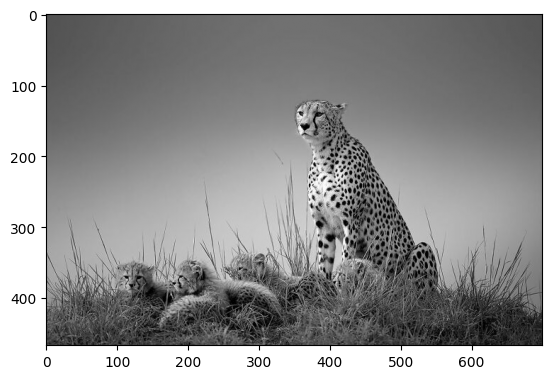

In [13]:
img = plt.imread('zdjecie.jpg')

plt.imshow(img, cmap='gray')
plt.show()

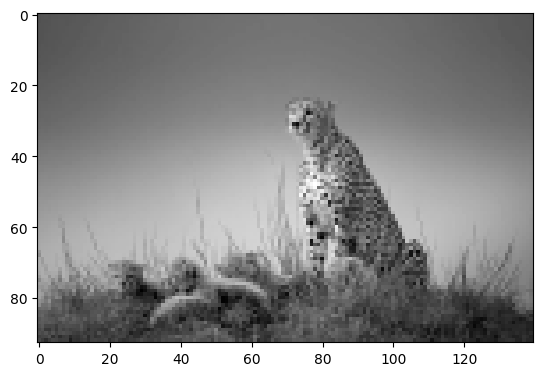

In [28]:
small = downscale(img, 5)

plt.imshow(small, cmap='gray')
plt.show()

In [16]:
def convolve_1d(signal, kernel):
    m = len(kernel)
    r = m // 2
    n = len(signal)

    out = np.zeros(n)

    for i in range(n):
        s = 0.0
        for k in range(m):
            idx = i + k - r
            if 0 <= idx < n:
                s += signal[idx] * kernel[k]
        out[i] = s

    return out

In [18]:
def interpolate_1d(signal, scale, kernel_fn):
    n = len(signal)
    new_n = n * scale

    out = np.zeros(new_n)

    for i in range(new_n):
        x = i / scale
        left = int(np.floor(x))
        right = min(left + 1, n - 1)

        t = x - left
        out[i] = (1 - t) * signal[left] + t * signal[right]

    t_vals = np.linspace(-1, 1, 21)
    kernel = kernel_fn(t_vals)

    if kernel.sum() != 0:
        kernel = kernel / kernel.sum()

    return convolve_1d(out, kernel)


In [19]:
def upscale(image, scale, kernel_fn):
    h, w = image.shape

    temp = np.zeros((h, w * scale))
    for i in range(h):
        temp[i] = interpolate_1d(image[i], scale, kernel_fn)

    new_h = h * scale
    result = np.zeros((new_h, w * scale))
    for j in range(temp.shape[1]):
        result[:, j] = interpolate_1d(temp[:, j], scale, kernel_fn)

    return result

In [ ]:
def h1(t):
    return np.where((t >= 0) & (t < 1), 1, 0)


def h2(t):
    return np.where((t >= -1/2) & (t < 1/2), 1, 0)


def h3(t):
    return np.where((t >= -1) & (t <= 1), 1 - abs(t), 0)


def h4(t):
    return np.sinc(t / np.pi)  # https://numpy.org/doc/stable/reference/generated/numpy.sinc.html#numpy.sinc

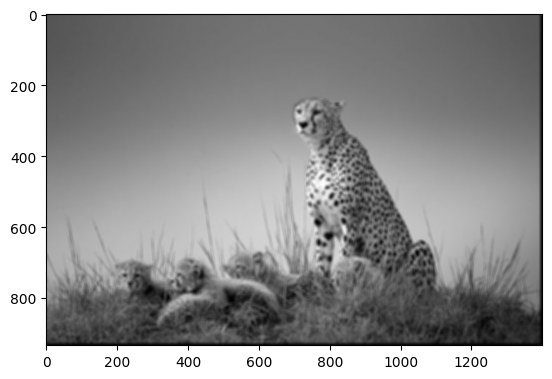

In [30]:
big = upscale(img, 2, h1)

plt.imshow(big, cmap='gray')
plt.show()